# Score-SG Experiments

This notebook mirrors the style of the existing experiment notebooks, but runs the pipeline with `algorithm="score-sg"`.
It builds the support graph once at `k_max`, extracts hierarchies for smaller values of `k`, and visualizes the resulting labels and timings.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))


In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs

from core_sg import CoreSGClusterer


In [3]:
from matplotlib.colors import to_rgba
def scatter_labels(ax, X_plot, labels, title):
    unique_labels = np.unique(labels)
    non_noise_labels = [lab for lab in unique_labels if lab != -1]

    cmap = plt.cm.get_cmap("tab20", max(1, len(non_noise_labels)))
    color_map = {lab: cmap(idx) for idx, lab in enumerate(non_noise_labels)}

    noise_mask = labels == -1
    cluster_mask = ~noise_mask

    if np.any(cluster_mask):
        cluster_colors = [color_map[lab] for lab in labels[cluster_mask]]
        ax.scatter(
            X_plot[cluster_mask, 0],
            X_plot[cluster_mask, 1],
            c=cluster_colors,
            s=18,
            alpha=0.80,
        )

    if np.any(noise_mask):
        ax.scatter(
            X_plot[noise_mask, 0],
            X_plot[noise_mask, 1],
            c="#cfcfcf",
            s=28,
            marker="x",
            alpha=0.95,
            linewidths=1.2,
        )

    ax.set_title(title)
    ax.set_xlabel("x0")
    ax.set_ylabel("x1")

## 1. Build a synthetic dataset

The setup stays close to the other notebooks so the results are easy to compare.


In [4]:
n_samples = 20000
n_features = 2
centers = 10
k_max = 30
seed = 42

print(
    f"Generating synthetic dataset: n={n_samples}, d={n_features}, centers={centers}, seed={seed}"
)
X, _ = make_blobs(
    n_samples=n_samples,
    n_features=n_features,
    centers=centers,
    random_state=seed,
    cluster_std=0.60,
)
X.shape


Generating synthetic dataset: n=20000, d=2, centers=10, seed=42


(20000, 2)

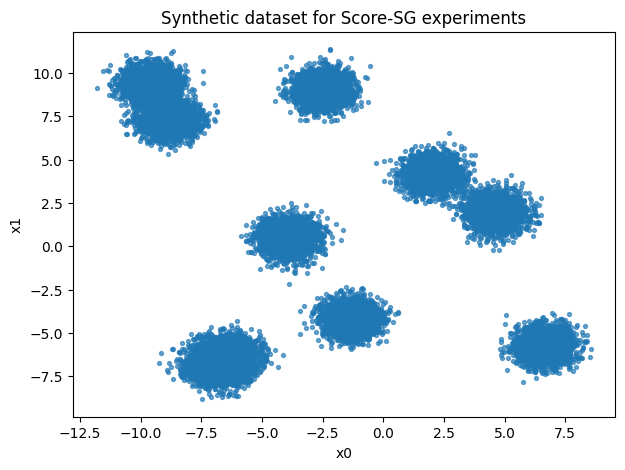

In [5]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=8, alpha=0.65)
plt.title("Synthetic dataset for Score-SG experiments")
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()


## 2. Build `CoreSG` with `algorithm="score-sg"`

The fit caches the support graph and the artifacts derived from `k_max`.


In [6]:
score_sg_clusterer = CoreSGClusterer(k_max=k_max, 
    metric="euclidean",
    p=2,
    verbose=1,
    no_noise=False,
    algorithm="score-sg",
    random_state=seed,
    match_reference_implementation=True,
)

In [7]:
t0 = time.time()
score_sg_clusterer.fit(X, k=k_max)
score_sg_ = score_sg_clusterer.core_sg_
build_score_sg_time = time.time() - t0
print(f"Score-SG build time (k_max={k_max}): {build_score_sg_time:.4f}s")


/home/gab04/Desktop/core-sg/.venv310/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


Core-SG build done in 21.03s
REWEIGHT Core_SG = 30 done in 0.41s
KRUSKAL Core_SG = 30 done in 0.16s
Score-SG build time (k_max=30): 23.5077s


In [8]:
print("labels_k_max_ shape:", score_sg_.labels_k_max_.shape)
print("unique labels at k_max:", np.unique(score_sg_.labels_k_max_))
score_sg_.labels_k_max_[:20]


labels_k_max_ shape: (20000,)
unique labels at k_max: [-1  0  1  2  3  4  5  6  7]


array([4, 0, 1, 5, 5, 1, 2, 2, 0, 2, 5, 4, 2, 6, 1, 6, 0, 6, 3, 1])

## 3. Extract hierarchies for smaller `k`

As in the other notebooks, we reuse the fitted structure and only reconstruct the hierarchy for each target value.


In [9]:
results = []
timings = {k_max: build_score_sg_time}
score_sg_.set_verbose(False)

for k_iter in range(k_max, 8, -2):
    t0 = time.time()
    score_sg_.extract_hierarchy_from_core_sg(k_iter)
    elapsed = time.time() - t0
    timings[k_iter] = elapsed if k_iter != k_max else timings[k_iter]
    results.append((k_iter, score_sg_.labels_.copy()))
    print(
        f"k={k_iter:>2} | hierarchy extraction time: {elapsed:.4f}s | unique labels: {len(np.unique(score_sg_.labels_))}"
    )


k=30 | hierarchy extraction time: 0.0000s | unique labels: 9
k=28 | hierarchy extraction time: 2.2491s | unique labels: 9
k=26 | hierarchy extraction time: 2.0619s | unique labels: 9
k=24 | hierarchy extraction time: 1.8516s | unique labels: 9
k=22 | hierarchy extraction time: 1.7965s | unique labels: 9
k=20 | hierarchy extraction time: 2.0309s | unique labels: 9
k=18 | hierarchy extraction time: 1.8309s | unique labels: 9
k=16 | hierarchy extraction time: 1.7872s | unique labels: 9
k=14 | hierarchy extraction time: 1.7723s | unique labels: 10
k=12 | hierarchy extraction time: 1.8291s | unique labels: 7
k=10 | hierarchy extraction time: 1.9757s | unique labels: 7


/tmp/ipykernel_12592/2704967769.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(1, len(non_noise_labels)))


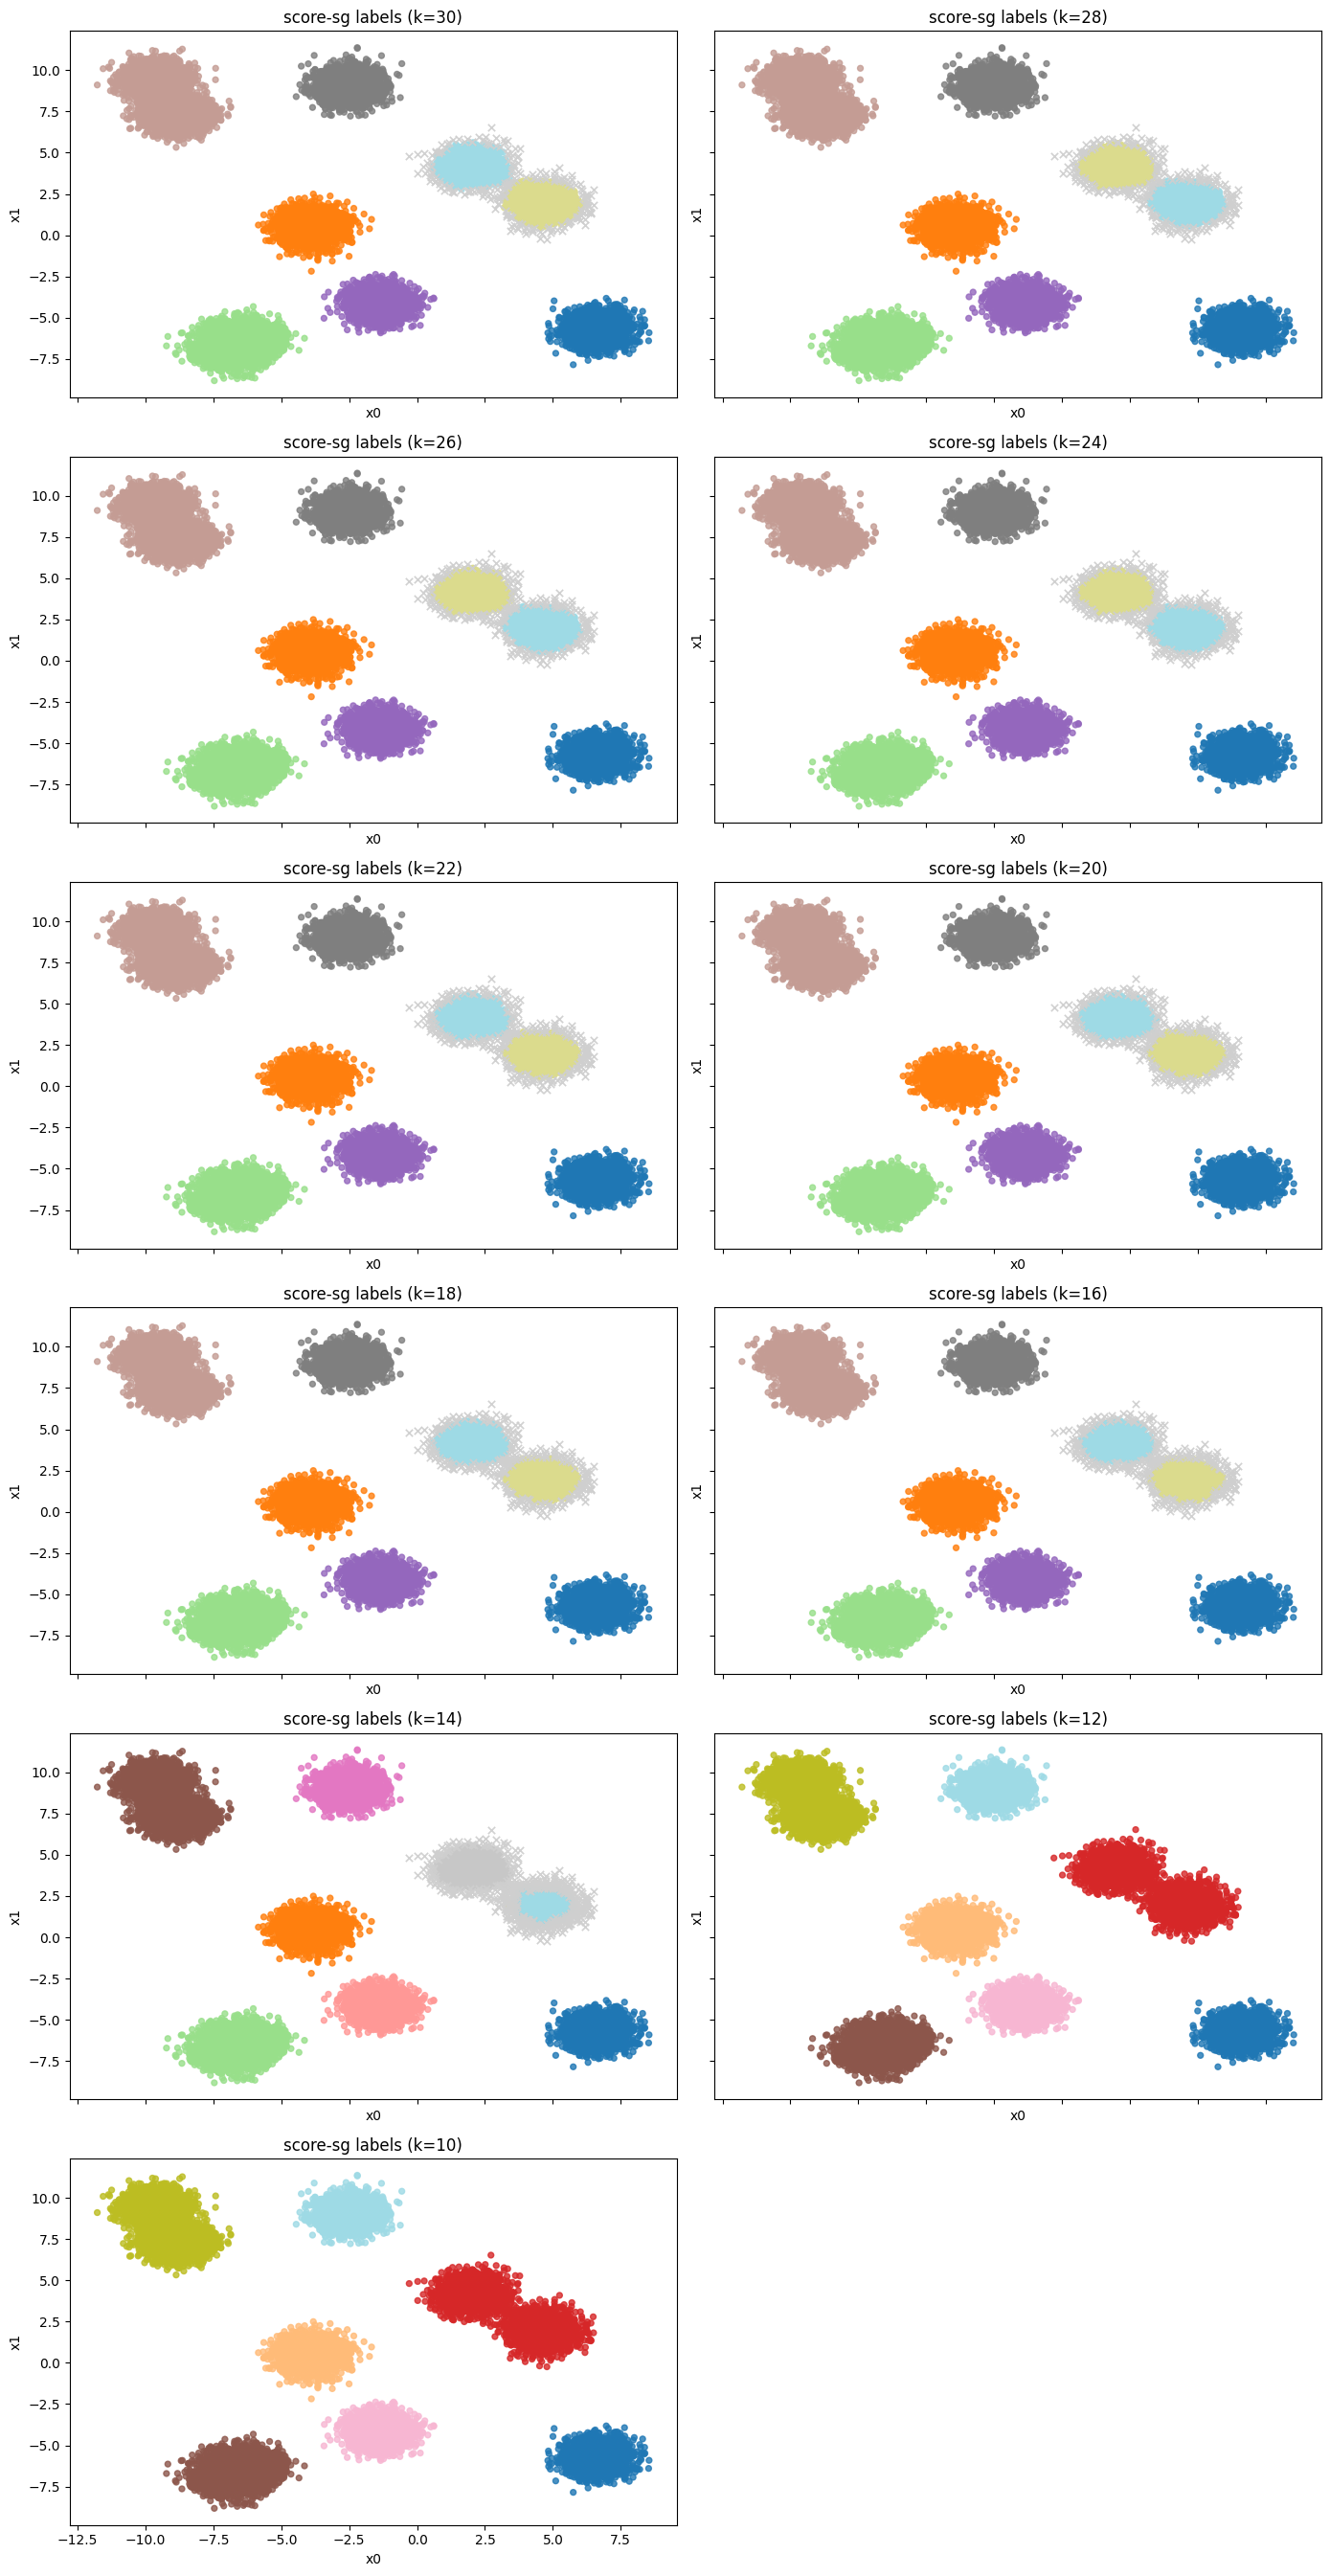

In [10]:
ncols = 2
nrows = int(np.ceil(len(results) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for idx, (k_iter, labels) in enumerate(results):
    scatter_labels(axes[idx], X, labels, f"score-sg labels (k={k_iter})")

for idx in range(len(results), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


## 4. Inspect cached distances and timings


In [11]:
k_probe = 12
print(f"First 10 approximate core distances for k={k_probe}:")
print(score_sg_.get_core_distance(k_probe)[:10])

mrd = score_sg_.get_core_sg_mutual_reachability_distance(k=k_probe)
print("MRD edge matrix shape:", mrd.shape)
mrd[:5]


First 10 approximate core distances for k=12:
[0.21612146 0.08762757 0.06807549 0.05393386 0.06884456 0.16324514
 0.08231032 0.06057044 0.10919805 0.04593119]
MRD edge matrix shape: (609870, 3)


array([[5.06500000e+03, 1.23330000e+04, 3.31188701e-02],
       [5.06500000e+03, 1.23330000e+04, 3.31188701e-02],
       [5.84000000e+02, 1.64910000e+04, 3.39212082e-02],
       [5.84000000e+02, 1.64910000e+04, 3.39212082e-02],
       [1.55410000e+04, 1.89270000e+04, 3.39879505e-02]])

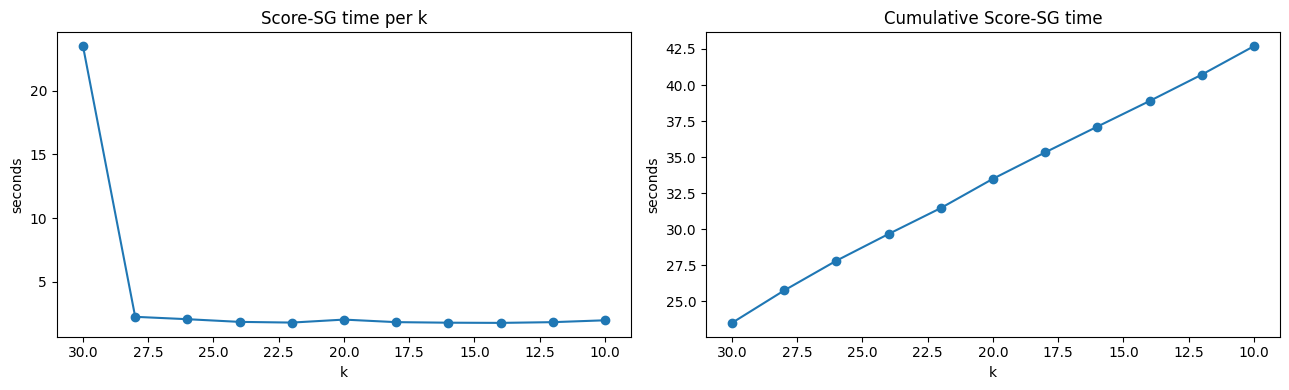

In [12]:
ks = sorted(timings.keys(), reverse=True)
extract_times = [timings[k] for k in ks]
cumulative_times = np.cumsum(extract_times)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ks, extract_times, marker="o")
axes[0].set_title("Score-SG time per k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("seconds")
axes[0].invert_xaxis()

axes[1].plot(ks, cumulative_times, marker="o")
axes[1].set_title("Cumulative Score-SG time")
axes[1].set_xlabel("k")
axes[1].set_ylabel("seconds")
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()
